In [1]:
!pip install shap


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- PHASE 5: EVALUATION & BUSINESS TRANSLATION ---
Running final inference...

--- FINAL MODEL METRIC GRID ---
Accuracy:  0.9900
Precision: 0.9682
Recall:    0.9952
F1-Score:  0.9815


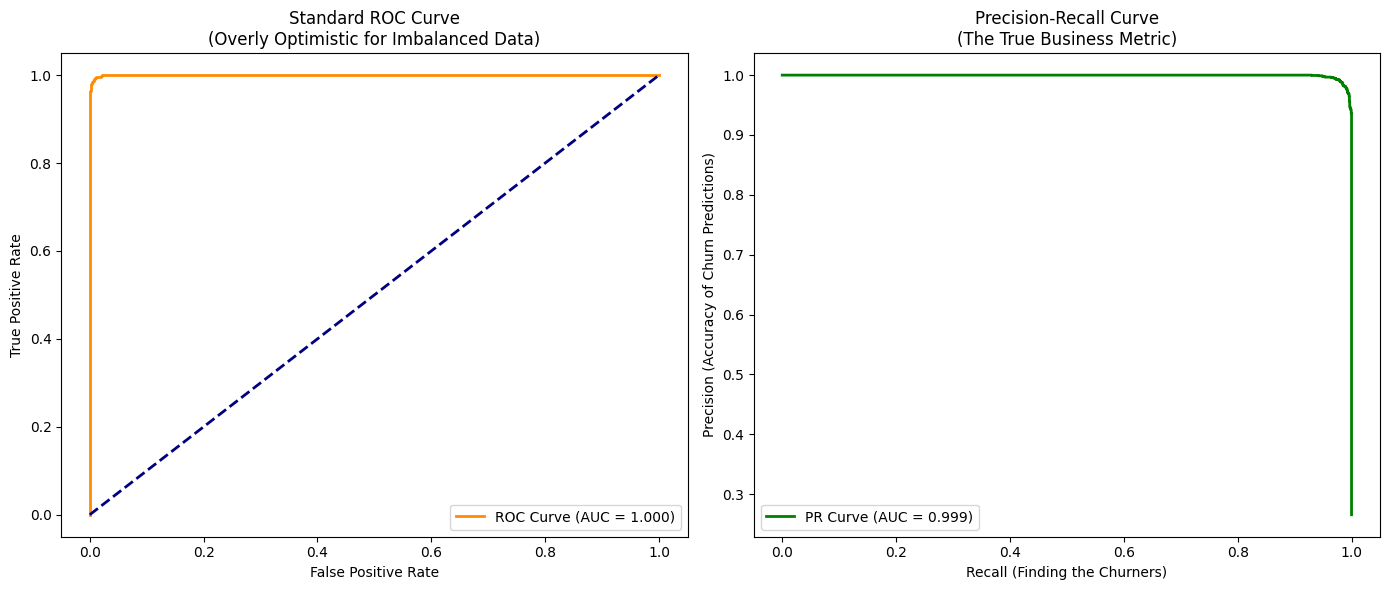


Calculating SHAP Values for Business Interpretability...
(Extracting XGBoost from the Stacker to run TreeExplainer...)


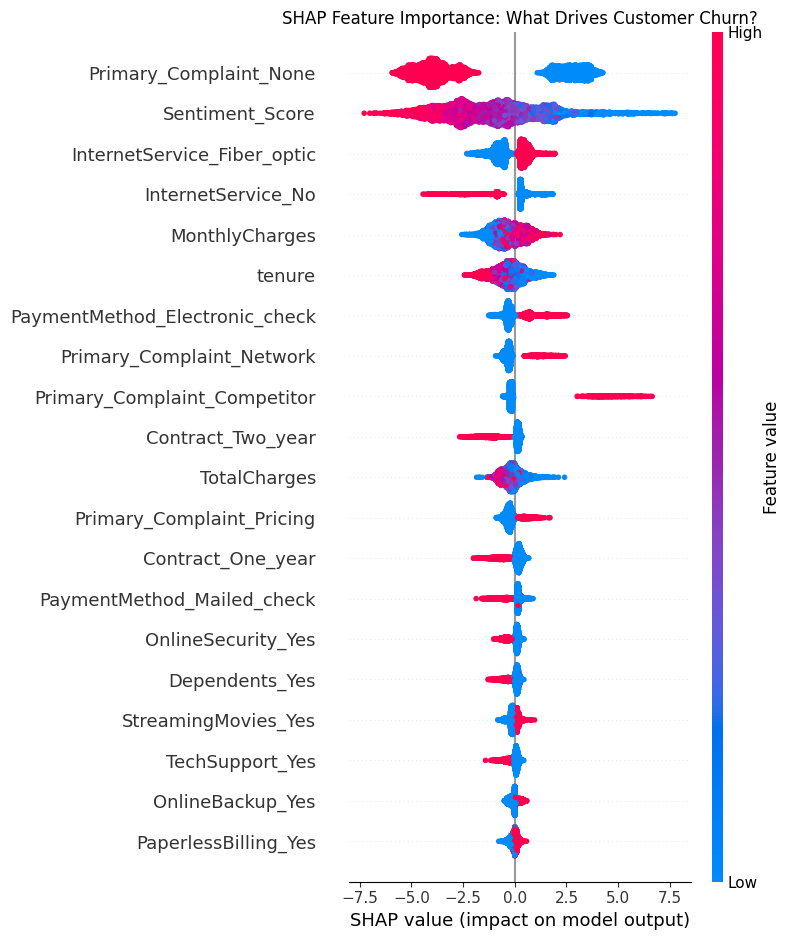


--- PHASE 5 COMPLETE ---


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import joblib
import shap
import re
import warnings
warnings.filterwarnings('ignore')

print("--- PHASE 5: EVALUATION & BUSINESS TRANSLATION ---")

# 1. Load Data & Model
# Adjusting paths since this notebook is inside the notebooks/ folder
df = pd.read_csv('../dataprocessed/processed_churn_data_encoded.csv')
X = df.drop(columns=['Churn'])
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
y = df['Churn']

stack_model = joblib.load('../models/churn_stacking_model.joblib')

# 2. Get Predictions for the Metric Grid & Curves
print("Running final inference...")
y_probs = stack_model.predict_proba(X)[:, 1]
y_pred = stack_model.predict(X)

# 3. The Metric Grid
print("\n--- FINAL MODEL METRIC GRID ---")
print(f"Accuracy:  {accuracy_score(y, y_pred):.4f}")
print(f"Precision: {precision_score(y, y_pred):.4f}")
print(f"Recall:    {recall_score(y, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y, y_pred):.4f}")

# 4. The Visual Showdown (ROC vs PR-AUC)
plt.figure(figsize=(14, 6))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y, y_probs)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Standard ROC Curve\n(Overly Optimistic for Imbalanced Data)')
plt.legend(loc="lower right")

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y, y_probs)
pr_auc = auc(recall, precision)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall (Finding the Churners)')
plt.ylabel('Precision (Accuracy of Churn Predictions)')
plt.title('Precision-Recall Curve\n(The True Business Metric)')
plt.legend(loc="lower left")

plt.tight_layout()
plt.savefig('../models/roc_pr_showdown.png') # Save for your report!
plt.show()

# 5. SHAP Interpretability

print("\nCalculating SHAP Values for Business Interpretability...")
print("(Extracting XGBoost from the Stacker to run TreeExplainer...)")

# Surgically extract XGBoost from the saved Stacking Classifier
xgb_base = stack_model.named_estimators_['xgb']

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_base)
shap_values = explainer.shap_values(X)

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance: What Drives Customer Churn?")
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary.png') # Save for your report!
plt.show()

print("\n--- PHASE 5 COMPLETE ---")